In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from datetime import datetime

# 1.1) Cargo el pickle de los datos con cluster
ruta = "../data/temperaturas_limpias_10_años_sin_racha_clusters.pkl"
df = pd.read_pickle(ruta)

# 1.2) Índice de fechas y columnas que usaremos
df["fecha"] = pd.to_datetime(df["fecha"])
df.set_index("fecha", inplace=True)
serie_full = df[["tmed", "cluster"]]
print("Primeras 5 filas:\n", serie_full.head(), "\n")
print("Recuento por cluster:\n", serie_full["cluster"].value_counts(), "\n")

clusters = sorted(serie_full["cluster"].unique())
print("Clusters disponibles:", clusters)


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Primeras 5 filas:
             tmed  cluster
fecha                    
2016-01-01  13.6        0
2016-01-02  13.6        0
2016-01-03  12.1        0
2016-01-04  12.7        0
2016-01-05  12.0        0 

Recuento por cluster:
 cluster
0    1008159
5     296355
2     255293
4     200485
3     193290
1      69316
Name: count, dtype: int64 

Clusters disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [2]:
def crear_ventanas(data, ventana=7):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i : i + ventana])
        y.append(data[i + ventana])
    X = np.array(X).reshape(-1, ventana, 1)
    y = np.array(y)
    return X, y

def predecir_multistep(modelo, ventana, pasos=7):
    preds = []
    vent = ventana.copy()
    for _ in range(pasos):
        p = modelo.predict(vent.reshape(1, -1, 1))[0,0]
        preds.append(p)
        vent = np.append(vent[1:], p)
    return np.array(preds).reshape(-1,1)


2. Bucle de entrenamiento por cluster


In [ ]:
# Parámetros
ventana = 7
ratio_train = 0.8

# DataFrame donde acumular resultados
resultados = []

for cl in clusters:
    dfc = serie_full[serie_full["cluster"] == cl]["tmed"].values.reshape(-1,1)
    #  Escalado
    scaler = MinMaxScaler()
    serie_s = scaler.fit_transform(dfc)
    #  Ventanas
    X, y = crear_ventanas(serie_s, ventana)
    #  Split train/test
    n_train = int(len(X) * ratio_train)
    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    #  Entreno RNN
    modelo = Sequential([
        SimpleRNN(50, input_shape=(ventana,1)),
        Dense(1)
    ])
    modelo.compile(optimizer="adam", loss="mse")
    modelo.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    # One-step
    y_pred_s = modelo.predict(X_test).flatten()
    reales = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    predichos = scaler.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    mae1 = mean_absolute_error(reales, predichos)
    rmse1 = np.sqrt(mean_squared_error(reales, predichos))
    # Multi-step (tomo la última ventana de test)
    ult = X_test[-1].flatten()
    preds7_s = predecir_multistep(modelo, ult, pasos=7).flatten()
    real7 = reales[-7:]  # últimos 7 valores reales
    pred7 = scaler.inverse_transform(preds7_s.reshape(-1,1)).flatten()
    mae7 = mean_absolute_error(real7, pred7)
    rmse7 = np.sqrt(mean_squared_error(real7, pred7))
    # Acumulo
    resultados.append({
        "cluster": cl,
        "one_step_MAE":   mae1,
        "one_step_RMSE":  rmse1,
        "multi7_MAE":     mae7,
        "multi7_RMSE":    rmse7
    })
    print(f"Cluster {cl} → One-step MAE: {mae1:.2f}, RMSE: {rmse1:.2f} | 7-step MAE: {mae7:.2f}, RMSE: {rmse7:.2f}")

df_res = pd.DataFrame(resultados).set_index("cluster")


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6301/6301 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Cluster 0 → One-step MAE: 1.58, RMSE: 2.06 | 7-step MAE: 0.71, RMSE: 0.83


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Cluster 1 → One-step MAE: 1.64, RMSE: 2.15 | 7-step MAE: 2.20, RMSE: 2.47


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1209/1209 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Cluster 3 → One-step MAE: 0.94, RMSE: 1.36 | 7-step MAE: 1.47, RMSE: 1.63


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1253/1253 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Cluster 4 → One-step MAE: 1.16, RMSE: 1.57 | 7-step MAE: 0.96, RMSE: 1.12


/Users/jorgeriverodelosrios/.venvs/global-env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1853/1853 ━━━━━━━━━━━━━━━━━━━━ 2s 781us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Cluster 5 → One-step MAE: 1.66, RMSE: 2.13 | 7-step MAE: 1.81, RMSE: 2.00


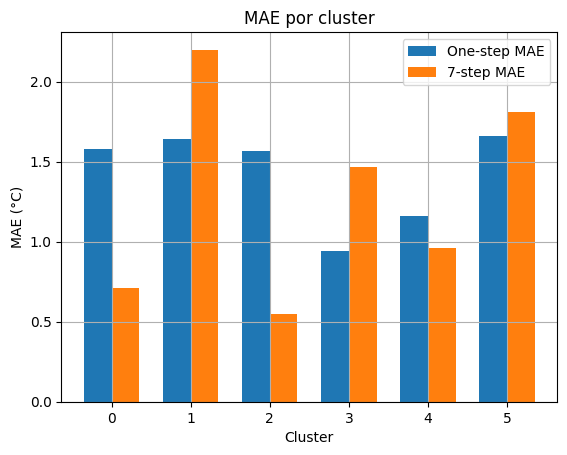

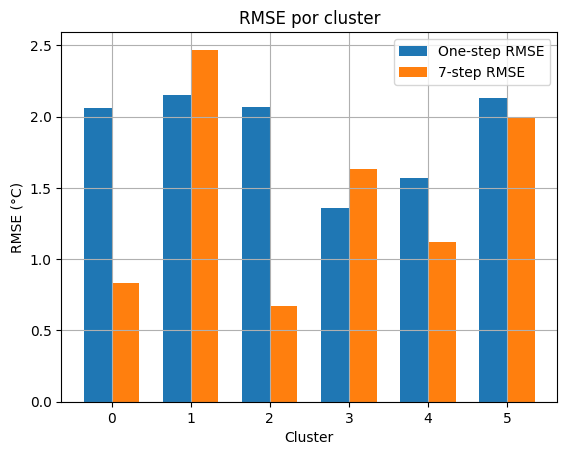

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crea el DataFrame
df_métricas = pd.DataFrame({
    'cluster':      [0, 1, 2, 3, 4, 5],
    'one_step_MAE': [1.58, 1.64, 1.57, 0.94, 1.16, 1.66],
    'multi7_MAE':   [0.71, 2.20, 0.55, 1.47, 0.96, 1.81],
    'one_step_RMSE':[2.06, 2.15, 2.07, 1.36, 1.57, 2.13],
    'multi7_RMSE':  [0.83, 2.47, 0.67, 1.63, 1.12, 2.00]
})

# Gráfico de MAE
x = df_métricas['cluster']
ancho = 0.35

plt.figure()
plt.bar(x - ancho/2, df_métricas['one_step_MAE'], ancho, label='One-step MAE')
plt.bar(x + ancho/2, df_métricas['multi7_MAE'],   ancho, label='7-step MAE')
plt.title('MAE por cluster')
plt.xlabel('Cluster')
plt.ylabel('MAE (°C)')
plt.xticks(x)
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de RMSE
plt.figure()
plt.bar(x - ancho/2, df_métricas['one_step_RMSE'], ancho, label='One-step RMSE')
plt.bar(x + ancho/2, df_métricas['multi7_RMSE'],   ancho, label='7-step RMSE')
plt.title('RMSE por cluster')
plt.xlabel('Cluster')
plt.ylabel('RMSE (°C)')
plt.xticks(x)
plt.legend()
plt.grid(True)
plt.show()
